In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, skew, mannwhitneyu, shapiro, weibull_min, weibull_max
import statsmodels.stats.power as smp
import statsmodels.api as sm
import scipy
# from lifelines import WeibullFitter

In [105]:
# Load the data.
df = pd.read_excel('Time_for_Bac_Fix_MutRate_Comparison.xlsx', sheet_name='All Time Distributions')
df.head()

,SOS,Spontaneous
0,19232,26374.0
1,11287,86400.0
2,21931,53988.0
3,19650,47586.0
4,26696,86400.0


### Data Cleaning

In [106]:
# Removing Outliers
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
# Remove outliers
df_cleaned = df.copy()
df_cleaned['SOS'] = remove_outliers(df, 'SOS')['SOS']
df_cleaned['Spontaneous'] = remove_outliers(df, 'Spontaneous')['Spontaneous']
df_cleaned.describe()

,SOS,Spontaneous
count,94.000000,90.000000
mean,21746.510638,61314.511111
std,3695.819212,23972.211420
min,12174.000000,20177.000000
25%,19232.000000,46438.000000
50%,21377.000000,53988.000000
75%,24377.750000,86400.000000
max,30816.000000,86400.000000


- SOS is the mutation rate with the SOS response.
- Spontaneous is a mutation rate without the SOS response, (100x slower).

### Descriptive Statistics

Weibull Parameters
Shape (k): 2.9215360882370973
Location (loc): 0
Scale (λ): 69018.9217113063 s
k = 2.92.  A value of k > 1 indicates the indicates that the event becomes more likely as time goes on.
Estimated time until event (50th percentile): 60881.45 seconds = 16.91 hours


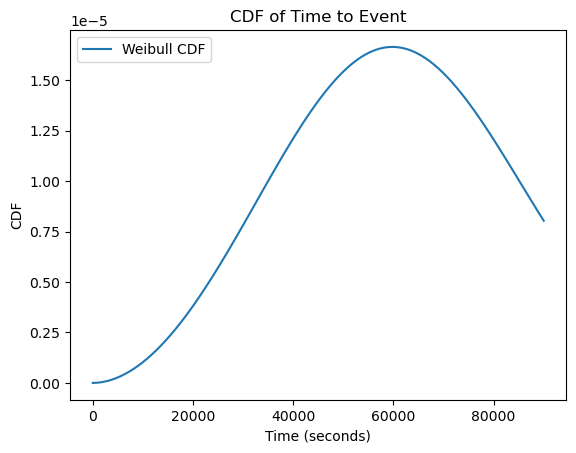

In [15]:
times = df['Spontaneous'].dropna()

# Censoring indicator (1 = event occurred, 0 = censored)
events = (times != 86400).astype(int)

# Fit Weibull distribution
params = weibull_min.fit(times, floc=0)

# Print the parameters (shape, loc, scale)
# Weibull Parameters:
#    Shape Parameter (k)
#    Location Parameter (loc)
#    Scale Parameter (λ)
print(f"Weibull Parameters\nShape (k): {params[0]}\nLocation (loc): {params[1]}\nScale (λ): {params[2]} s")
print("k = {:.2f}.  A value of k > 1 indicates the indicates that the event becomes more likely as time goes on.".format(params[0]))

# Estimate the time until event for a given percentile
percentile = 0.5  # Median time to event
time_to_event = weibull_min.ppf(percentile, *params)

print(f"Estimated time until event (50th percentile): {time_to_event:.2f} seconds = {(time_to_event)/3600:.2f} hours")

# Plot the cumulative distribution function (CDF)
x = np.linspace(0, 90000, 100)
den_func = weibull_min.pdf(x, *params)

plt.plot(x, den_func, label='Weibull CDF')
plt.xlabel('Time (seconds)')
plt.ylabel('CDF')
plt.title('CDF of Time to Event')
plt.legend()
plt.show()

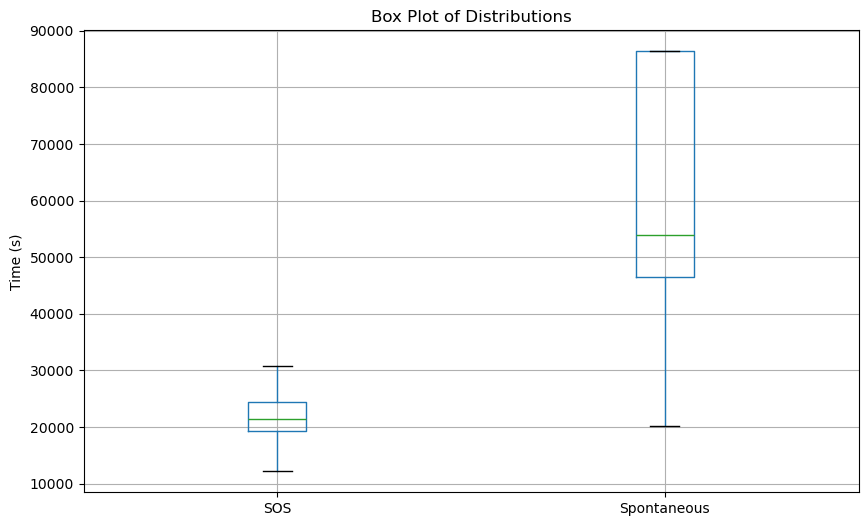

In [13]:
# Visualize the Data
plt.figure(figsize=(10, 6))
df_cleaned.boxplot()
plt.title('Box Plot of Distributions')
plt.ylabel('Time (s)')
plt.show()

### Regression Analysis

In [57]:
# Prepare the combined dataset
df_sos = df[['SOS']].rename(columns={'SOS': 'Time'}).assign(Group='SOS')
df_spontaneous = df[['Spontaneous']].rename(columns={'Spontaneous': 'Time'}).assign(Group='Spontaneous')
combined_df = pd.concat([df_sos, df_spontaneous], ignore_index=True)
combined_df

,Time,Group
0,19232.0,SOS
1,11287.0,SOS
2,21931.0,SOS
3,19650.0,SOS
4,26696.0,SOS
...,...,...
195,NaN,Spontaneous
196,NaN,Spontaneous
197,NaN,Spontaneous
198,NaN,Spontaneous


In [93]:
# Censoring indicator (1 = event occurred, 0 = censored)
combined_df['Event'] = (combined_df['Time'] != 86400).astype(int)
# Then remove NaN values from 'Time'.
combined_df_clean = combined_df.dropna(subset=['Time'])
combined_df_clean

,Time,Group,Event
0,19232.0,SOS,1
1,11287.0,SOS,1
2,21931.0,SOS,1
3,19650.0,SOS,1
4,26696.0,SOS,1
...,...,...,...
185,86400.0,Spontaneous,0
186,56673.0,Spontaneous,1
187,50545.0,Spontaneous,1
188,26966.0,Spontaneous,1


In [ ]:
# Fit Weibull distribution for each group with cleaned data
sos_times_clean = combined_df_clean[combined_df_clean['Group'] == 'SOS']['Time']
spontaneous_times_clean = combined_df_clean[combined_df_clean['Group'] == 'Spontaneous']['Time']

params_sos_clean = weibull_min.fit(sos_times_clean, floc=0)
params_spontaneous_clean = weibull_min.fit(spontaneous_times_clean, floc=0)

# Print the cleaned parameters
weibull_params_clean = {
    'SOS': {
        'shape': params_sos_clean[0],
        'location': params_sos_clean[1],
        'scale': params_sos_clean[2]
    },
    'Spontaneous': {
        'shape': params_spontaneous_clean[0],
        'location': params_spontaneous_clean[1],
        'scale': params_spontaneous_clean[2]
    }
}

# Prepare the combined cleaned dataset with Weibull-fitted values
combined_df_clean['Shape'] = combined_df_clean['Group'].apply(lambda x: weibull_params_clean[x]['shape'])
combined_df_clean['Scale'] = combined_df_clean['Group'].apply(lambda x: weibull_params_clean[x]['scale'])

# Create a binary variable for the group
combined_df_clean['Group_binary'] = combined_df_clean['Group'].apply(lambda x: 1 if x == 'Spontaneous' else 0)
combined_df_clean['Group_binary'] = combined_df_clean['Group_binary'].astype(float)

In [97]:
# Check the structure of the dataset
combined_df_clean.head()

,Time,Group,Event,Shape,Scale,Group_binary
0,19232.0,SOS,1,4.608176,23531.916143,0.0
1,11287.0,SOS,1,4.608176,23531.916143,0.0
2,21931.0,SOS,1,4.608176,23531.916143,0.0
3,19650.0,SOS,1,4.608176,23531.916143,0.0
4,26696.0,SOS,1,4.608176,23531.916143,0.0


In [100]:
# Replace censored times with the estimated mean time from Weibull distribution
def estimate_weibull_mean(params):
    shape, loc, scale = params
    return scale * scipy.special.gamma(1 + 1/shape)

estimated_mean_spontaneous = estimate_weibull_mean(params_spontaneous_clean)
combined_df_clean_estimate = combined_df_clean.copy()
combined_df_clean_estimate.loc[(combined_df_clean['Group'] == 'Spontaneous') & (combined_df_clean['Time'] == 86400), 'Time'] = estimated_mean_spontaneous

In [102]:
# All the 24h limits have been replaced.
combined_df_clean_estimate[combined_df_clean_estimate['Time']==86400]

,Time,Group,Event,Shape,Scale,Group_binary


In [104]:
# Define the dependent variable (Time)
y = combined_df_clean['Time']

# Define the independent variables (Group)
X = combined_df_clean[['Group_binary']]

# Add a constant to the independent variables
X = sm.add_constant(X)

# Perform OLS regression
model = sm.OLS(y, X).fit()

# Print the summary of the regression
model_summary = model.summary()
print(model_summary)

                            OLS Regression Results                            
Dep. Variable:                   Time   R-squared:                       0.583
Model:                            OLS   Adj. R-squared:                  0.581
Method:                 Least Squares   F-statistic:                     262.6
Date:                Wed, 03 Jul 2024   Prob (F-statistic):           1.57e-37
Time:                        13:27:52   Log-Likelihood:                -2117.7
No. Observations:                 190   AIC:                             4239.
Df Residuals:                     188   BIC:                             4246.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         2.165e+04   1684.807     12.848   

In [12]:
df.describe()

,SOS,Spontaneous
count,100.000000,90.000000
mean,21647.050000,61314.511111
std,4735.276292,23972.211420
min,11287.000000,20177.000000
25%,19180.750000,46438.000000
50%,21349.500000,53988.000000
75%,24439.250000,86400.000000
max,39176.000000,86400.000000


### Data Normalization and Histograms

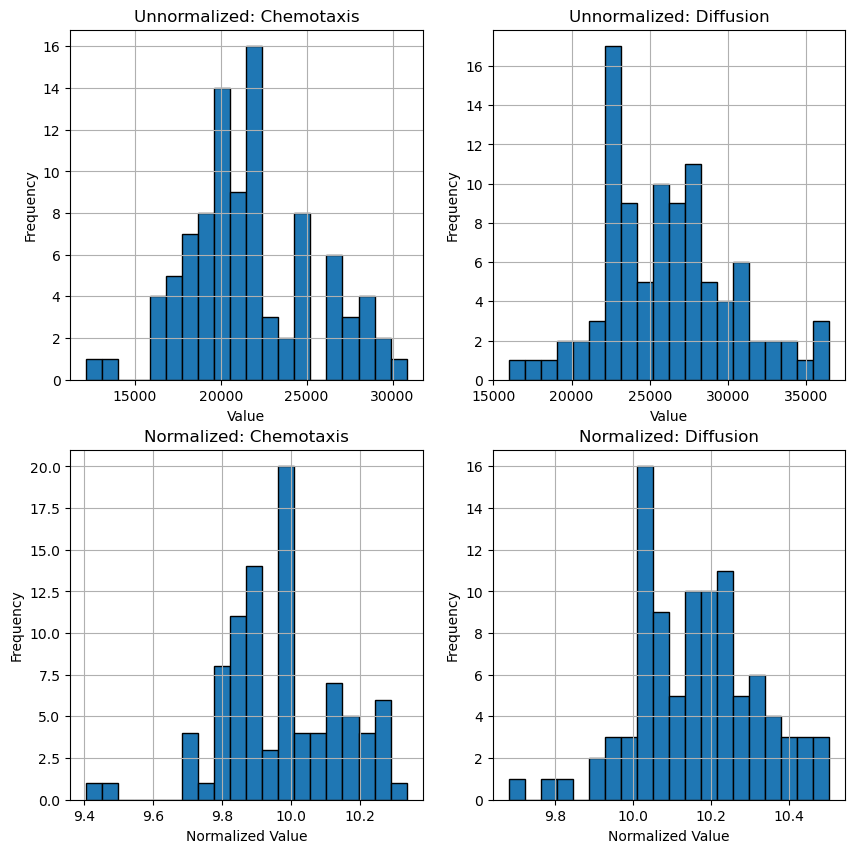

In [8]:
normalized_df_cleaned = df_cleaned.apply(lambda x: np.log(x))

# Number of columns to plot
num_columns = len(df_cleaned.columns)

# Create subplots
fig, axs = plt.subplots(2, num_columns, figsize=(5 * num_columns, 10))

# Ensure axs is 2-dimensional, even if there is only one column
if num_columns == 1:
    axs = np.array([[axs[0]], [axs[1]]])

# Plot histograms for each column in unnormalized data
for i, column in enumerate(df_cleaned.columns):
    df_cleaned[column].hist(ax=axs[0, i], bins=20, edgecolor='k')
    axs[0, i].set_title(f'Unnormalized: {column}')
    axs[0, i].set_xlabel('Value')
    axs[0, i].set_ylabel('Frequency')

# Plot histograms for each column in normalized data
for i, column in enumerate(normalized_df_cleaned.columns):
    normalized_df_cleaned[column].hist(ax=axs[1, i], bins=20, edgecolor='k')
    axs[1, i].set_title(f'Normalized: {column}')
    axs[1, i].set_xlabel('Normalized Value')
    axs[1, i].set_ylabel('Frequency')

### Power Analysis

In [9]:
# Removing Outliers
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
# Remove outliers
df_cleaned = df.copy()
df_cleaned['Chemotaxis'] = remove_outliers(df, 'Chemotaxis')['Chemotaxis']
df_cleaned['Diffusion'] = remove_outliers(df, 'Diffusion')['Diffusion']
df_cleaned.describe()

,Chemotaxis,Diffusion
count,94.000000,96.000000
mean,21746.510638,26221.177083
std,3695.819212,4155.321960
min,12174.000000,16003.000000
25%,19232.000000,23099.750000
50%,21377.000000,25591.500000
75%,24377.750000,28543.750000
max,30816.000000,36457.000000


**Comparing Normal Equation data to others.**

Comparing the chemotaxis data, (unaltered model), with the diffusion model.

In [10]:
# Calculate Skewness of a data set.
skew_chemotaxis = skew(df['Chemotaxis'].dropna())
skew_diffusion = skew(df['Diffusion'].dropna())

# Mann-Whitney U Test
u_stat, p_value_u = mannwhitneyu(df['Chemotaxis'].dropna(), df['Diffusion'].dropna())

skew_chemotaxis, skew_diffusion, u_stat, p_value_u

(0.5762171010737761, -1.0111309627711793, 2405.0, 2.3041473088725123e-10)

Skewness:
- Both distributions are skewed, as one can tell by their score.
- Chemotaxis: 0.576
- The distribution is slightly skewed to the right.
- Diffusion: -1.011
- The distribution has a skew which goes to the left more.

Median:
- Chemotaxis: 21377.0
- Diffusion: 25591.5

Mann-Whitney U Test:
- P-value: The the extremely low p-value is less than the common significance level of 0.05.  We can safely conclude that the null hypothesis is rejected and there is significant differences between the two distributions.

Conclusion:
    There is significant differences between the two distributions, and the time for fixing with chemotaxis is more likely to be lower as the median is lower than diffusion.

**The Shapiro-Wilk test shows the data is not normally distributed so we don't need the T-Test, just the Mann-Whiteney U Test**

In [16]:
# Shapiro-Wilk Test
shapiro_chemotaxis = shapiro(df['Chemotaxis'].dropna())
shapiro_diffusion = shapiro(df['Diffusion'].dropna())

shapiro_chemotaxis, shapiro_diffusion

(ShapiroResult(statistic=0.9481931924819946, pvalue=0.0006319586536847055),
 ShapiroResult(statistic=0.9173464775085449, pvalue=1.0206168553850148e-05))

In [11]:
# T-Test
t_stat, p_value_u = ttest_ind(df['Chemotaxis'].dropna(), df['Diffusion'].dropna())

t_stat, p_value_u

(-5.3263858890992815, 2.7084511163502364e-07)

**Conclusion:**

    Even with the skew, the 75 percentile for chemotaxis is still lower than diffusion, (24377.75 vs. 28543.75).
    The 25 percentile for chemotaxis vs. diffusion: 19232.00 vs. 23099.75.

    The median of chemotaxis is lower than diffusion, (21377.0 vs. 25591.5).

    The largest factor for how quickly a mutant will fix into a population is the stochastic Poisson distribution which determines the rate of mutation, and just as importantly, the proximity of a mutation occuring.  A mutation occuring near or within the antibiotic alongside how quickly that mutant migrates towards the area to fix in a low wildtype population is the greatest variable for time.  The reason for the increased variability in both distributions of mutant fixation time is primarily due to this reason.  This variability is partially mitigated by removing outliers > 1.5*IQR.

    Even with the increased variability, chemotaxis is shown to enhance time to fixation.  The magnitude of this effect is lessened by the model being one dimensional, as random diffusion away from higher population concentrations is still directed up the antibiotic gradient.  If this model was increased to 2 dimensions, chemotaxis would play a significantly greater effection on directed migration towards food.